In [14]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from sklearn.model_selection import train_test_split

In [15]:
insurance_data = pd.read_csv("insurance.csv")

X = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]

X = pd.get_dummies(X, columns = ["region"], drop_first = True, dtype = int)

X["sex"] = X["sex"].map({"female": 1, "male": 0})
X["smoker"] = X["smoker"].map({"yes": 1, "no": 0})

X["age_smoker_interaction"]= X["age"] * X["smoker"]
X["bmi_smoker"]= X["bmi"] * X["smoker"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

MSE for alpha=0.001:  20922599.871035974
MSE for alpha=0.1:  20921803.69843139
MSE for alpha=1:  20914832.635089148
MSE for alpha=2:  20908106.779954527
MSE for alpha=5:  20890881.000633504
MSE for alpha=10:  20872844.794796687
MSE for alpha=20:  20877828.53237883
MSE for alpha=30:  20937537.13393977
MSE for alpha=40:  21046489.293890774
MSE for alpha=50:  21196929.869608898
MSE for alpha=100:  22423172.68602322


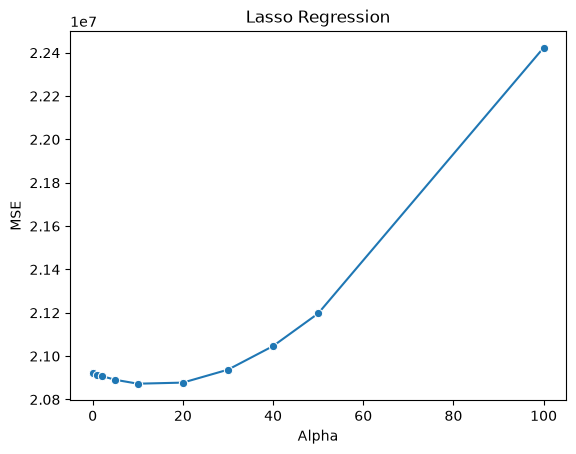

In [16]:
import seaborn as sns 
import matplotlib.pyplot as plt

alphas = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]
mses = []

for a in alphas:
    lasso_model = Lasso(alpha = a)
    lasso_model.fit(X_train, y_train)

    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"MSE for alpha={a}: ", mse)
    mses.append(mse)

sns.lineplot(x=alphas, y=mses, marker = "o")
plt.xlabel("Alpha")
plt.ylabel("MSE")
plt.title("Lasso Regression")
plt.show()

In [19]:
from sklearn.linear_model import LassoCV

a = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]

lasso_cv_model = LassoCV(
    alphas = a,
    cv = 5,
    max_iter = 1000,
    random_state = 42
)

lasso_cv_model.fit(X_train, y_train)

print("Optimal alpha:", lasso_cv_model.alpha_)

y_pred_cv = lasso_cv_model.predict(X_test)
mse_cv = mean_squared_error(y_test, y_pred_cv)
r2 = r2_score(y_test, y_pred)
print("mse = ", mse)
print("s2 = ", r2)

Optimal alpha: 0.001
mse =  22423172.68602322
s2 =  0.8555661455616376
